# Credit Card Fraud Detection using `creditcard.csv`

This notebook works directly with the `creditcard.csv` dataset (Source: Kaggle).

**Dataset assumptions**
- Input file: `creditcard.csv`
- Target column: `Class`
- Fraud class: `1`
- Non-fraud class: `0`

**Goal**
Build and compare several fraud detection models, then evaluate them on a holdout test set and estimate business impact using a simple cost framework.


## Notebook Structure

1. Imports and display settings
2. File paths
3. Load datasets
4. Helper functions
5. Feature engineering
6. Categorical encoding
7. Prepare modeling dataset
8. Exploratory analysis
9. Feature selection
10. Scaling for Logistic Regression
11. Baseline Logistic Regression
12. Logistic Regression with SMOTE and ADASYN
13. Decision Tree models
14. Random Forest models
15. Model comparison
16. Holdout test evaluation
17. Fraud prediction sample output
18. Business cost analysis
19. Final notes and next steps


## 1. Imports and display settings

In [3]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. File paths

In [5]:

# Primary path options for convenience
DATA_FILE = Path("creditcard.csv")
ALT_DATA_FILE = Path("data/creditcard.csv")

if DATA_FILE.exists():
    csv_path = DATA_FILE
elif ALT_DATA_FILE.exists():
    csv_path = ALT_DATA_FILE
else:
    raise FileNotFoundError(
        "Could not find 'creditcard.csv'. Place it in the notebook folder or in a 'data/' folder."
    )

print(f"Using dataset: {csv_path.resolve()}")


Using dataset: C:\Users\dshob\Assignments\Project (Credit-card-fraud-detection)\creditcard.csv


## 3. Load datasets

In [7]:

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())

print("\nColumn summary:")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values
}))


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0



Column summary:


,column,dtype,missing_values
0,Time,float64,0
1,V1,float64,0
2,V2,float64,0
3,V3,float64,0
4,V4,float64,0
5,V5,float64,0
6,V6,float64,0
7,V7,float64,0
8,V8,float64,0
9,V9,float64,0


## 4. Helper functions

In [9]:

def model_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
    }

def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = model_metrics(y_test, y_pred, y_proba)
    metrics["Model"] = name
    return model, metrics

def show_confusion(y_true, y_pred, labels=("Non-Fraud", "Fraud")):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    return cm_df

def business_cost_summary(y_true, y_pred, fn_cost=500, fp_cost=10):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    return {
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Cost per False Negative": fn_cost,
        "Cost per False Positive": fp_cost,
        "Estimated Total Cost": total_cost
    }

def plot_top_feature_importance(importances, feature_names, top_n=15, title="Top Feature Importances"):
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    return imp_df


## 5. Feature engineering

In [11]:

# Copy the dataset for feature work
work_df = df.copy()

# Basic engineered features for this dataset
# These keep the notebook structure aligned with a standard ML workflow.
work_df["Amount_log"] = np.log1p(work_df["Amount"])
work_df["Hour"] = (work_df["Time"] // 3600) % 24
work_df["Time_day"] = work_df["Time"] / (24 * 3600)

print("Feature engineering completed.")
display(work_df.head())


Feature engineering completed.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Hour,Time_day
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,5.0148,0.0000,0.0000
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,1.3056,0.0000,0.0000
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,5.9393,0.0000,0.0000
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0,4.8243,0.0000,0.0000
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0,4.2625,0.0000,0.0000


## 6. Categorical encoding

In [13]:

# This dataset is already fully numeric.
categorical_cols = work_df.select_dtypes(include=["object", "category"]).columns.tolist()

if categorical_cols:
    work_df = pd.get_dummies(work_df, columns=categorical_cols, drop_first=True)
    print("Encoded categorical columns:", categorical_cols)
else:
    print("No categorical columns found. Encoding step not required for this dataset.")


No categorical columns found. Encoding step not required for this dataset.


## 7. Prepare modeling dataset

In [15]:

TARGET = "Class"

X = work_df.drop(columns=[TARGET])
y = work_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution (full dataset):")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

print("\nTarget distribution (train):")
display(y_train.value_counts(normalize=True).rename("proportion").to_frame())

print("\nTarget distribution (test):")
display(y_test.value_counts(normalize=True).rename("proportion").to_frame())


Training shape: (227845, 33)
Test shape: (56962, 33)

Target distribution (full dataset):


,proportion
Class,
0,0.9983
1,0.0017



Target distribution (train):


,proportion
Class,
0,0.9983
1,0.0017



Target distribution (test):


,proportion
Class,
0,0.9983
1,0.0017


## 8. Exploratory analysis

,dtype,missing,nunique
Time,float64,0,124592
V1,float64,0,275663
V2,float64,0,275663
V3,float64,0,275663
V4,float64,0,275663
V5,float64,0,275663
V6,float64,0,275663
V7,float64,0,275663
V8,float64,0,275663
V9,float64,0,275663


Class counts:


Class
0    284315
1       492
Name: count, dtype: int64

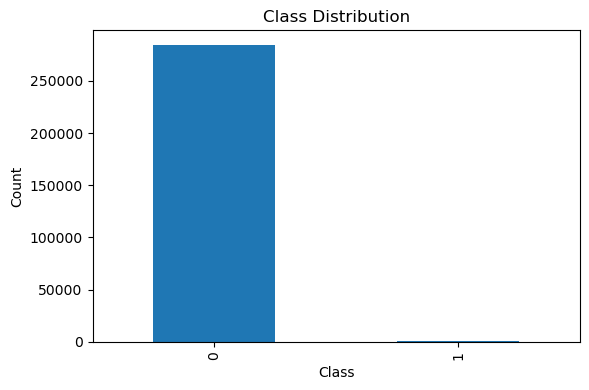

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
Amount,"284,807.0000",88.3496,250.1201,0.0000,5.6000,22.0000,77.1650,"25,691.1600"
Amount_log,"284,807.0000",3.1522,1.6566,0.0000,1.8871,3.1355,4.3588,10.1539
Hour,"284,807.0000",14.0465,5.8359,0.0000,10.0000,15.0000,19.0000,23.0000
Time_day,"284,807.0000",1.0974,0.5496,0.0000,0.6273,0.9802,1.6125,1.9999
Class,"284,807.0000",0.0017,0.0415,0.0000,0.0000,0.0000,0.0000,1.0000


In [17]:

summary_df = pd.DataFrame({
    "dtype": work_df.dtypes.astype(str),
    "missing": work_df.isna().sum(),
    "nunique": work_df.nunique()
})
display(summary_df.head(15))

print("Class counts:")
display(work_df["Class"].value_counts())

plt.figure(figsize=(6, 4))
work_df["Class"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

display(work_df[["Time", "Amount", "Amount_log", "Hour", "Time_day", "Class"]].describe().T)


## 9. Feature selection

In [19]:

# For this dataset, the features are already curated and anonymized.
# We remove only zero-variance columns if any appear.
nunique = X_train.nunique()
selected_features = nunique[nunique > 1].index.tolist()

X_train_fs = X_train[selected_features].copy()
X_test_fs = X_test[selected_features].copy()

print(f"Selected {len(selected_features)} features out of {X_train.shape[1]}.")
print("Sample selected features:", selected_features[:10])


Selected 33 features out of 33.
Sample selected features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


## 10. Scaling for Logistic Regression

In [21]:

# Logistic Regression usually benefits from scaling.
# Tree-based models will use the unscaled selected features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fs)
X_test_scaled = scaler.transform(X_test_fs)

print("Scaled datasets prepared for Logistic Regression.")
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled datasets prepared for Logistic Regression.
Scaled train shape: (227845, 33)
Scaled test shape: (56962, 33)


## 11. Baseline Logistic Regression

In [23]:

baseline_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight=None
)

baseline_lr.fit(X_train_scaled, y_train)
baseline_lr_pred = baseline_lr.predict(X_test_scaled)
baseline_lr_proba = baseline_lr.predict_proba(X_test_scaled)[:, 1]

baseline_lr_metrics = model_metrics(y_test, baseline_lr_pred, baseline_lr_proba)
display(pd.DataFrame([{"Model": "Baseline Logistic Regression", **baseline_lr_metrics}]))

print(classification_report(y_test, baseline_lr_pred, digits=4))
display(show_confusion(y_test, baseline_lr_pred))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Baseline Logistic Regression,0.9992,0.8333,0.6633,0.7386,0.9602,0.7390


              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8333    0.6633    0.7386        98

    accuracy                         0.9992     56962
   macro avg     0.9164    0.8315    0.8691     56962
weighted avg     0.9991    0.9992    0.9991     56962



,Non-Fraud,Fraud
Non-Fraud,56851,13
Fraud,33,65


## 12. Logistic Regression with SMOTE and ADASYN

In [25]:

smote_lr = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

adasyn_lr = ImbPipeline(steps=[
    ("adasyn", ADASYN(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

smote_lr.fit(X_train_fs, y_train)
adasyn_lr.fit(X_train_fs, y_train)

smote_lr_pred = smote_lr.predict(X_test_fs)
smote_lr_proba = smote_lr.predict_proba(X_test_fs)[:, 1]

adasyn_lr_pred = adasyn_lr.predict(X_test_fs)
adasyn_lr_proba = adasyn_lr.predict_proba(X_test_fs)[:, 1]

lr_resampling_results = pd.DataFrame([
    {"Model": "Logistic Regression + SMOTE", **model_metrics(y_test, smote_lr_pred, smote_lr_proba)},
    {"Model": "Logistic Regression + ADASYN", **model_metrics(y_test, adasyn_lr_pred, adasyn_lr_proba)},
])

display(lr_resampling_results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression + SMOTE,0.9896,0.1308,0.8980,0.2283,0.9757,0.7401
1,Logistic Regression + ADASYN,0.9890,0.1246,0.8980,0.2189,0.9757,0.7388


## 13. Decision Tree models

In [26]:

dt_default = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

dt_balanced = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_depth=6,
    min_samples_leaf=5
)

dt_default.fit(X_train_fs, y_train)
dt_balanced.fit(X_train_fs, y_train)

dt_default_pred = dt_default.predict(X_test_fs)
dt_default_proba = dt_default.predict_proba(X_test_fs)[:, 1]

dt_balanced_pred = dt_balanced.predict(X_test_fs)
dt_balanced_proba = dt_balanced.predict_proba(X_test_fs)[:, 1]

dt_results = pd.DataFrame([
    {"Model": "Decision Tree - Default", **model_metrics(y_test, dt_default_pred, dt_default_proba)},
    {"Model": "Decision Tree - Balanced", **model_metrics(y_test, dt_balanced_pred, dt_balanced_proba)},
])

display(dt_results)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree - Default,0.9991,0.7300,0.7449,0.7374,0.8722,0.5442
1,Decision Tree - Balanced,0.9763,0.0597,0.8673,0.1118,0.9121,0.4643


## 14. Random Forest models

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Default,0.9996,0.9412,0.8163,0.8743,0.9571,0.8714
1,Random Forest - Balanced,0.9995,0.9605,0.7449,0.8391,0.9521,0.8706


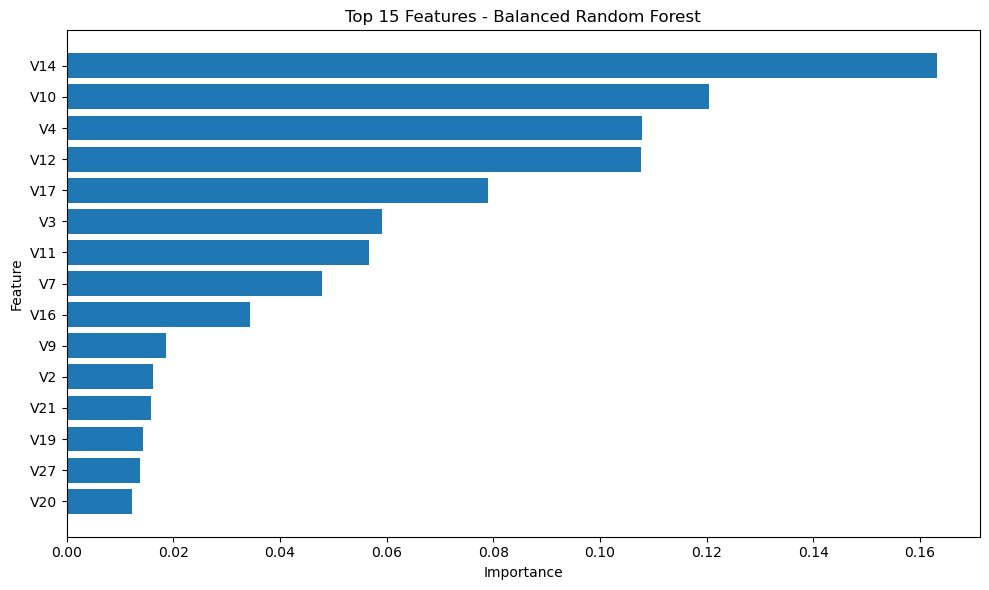

,feature,importance
14,V14,0.1631
10,V10,0.1204
4,V4,0.1079
12,V12,0.1076
17,V17,0.0790
3,V3,0.0591
11,V11,0.0568
7,V7,0.0479
16,V16,0.0344
9,V9,0.0187


In [28]:

rf_default = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_default.fit(X_train_fs, y_train)
rf_balanced.fit(X_train_fs, y_train)

rf_default_pred = rf_default.predict(X_test_fs)
rf_default_proba = rf_default.predict_proba(X_test_fs)[:, 1]

rf_balanced_pred = rf_balanced.predict(X_test_fs)
rf_balanced_proba = rf_balanced.predict_proba(X_test_fs)[:, 1]

rf_results = pd.DataFrame([
    {"Model": "Random Forest - Default", **model_metrics(y_test, rf_default_pred, rf_default_proba)},
    {"Model": "Random Forest - Balanced", **model_metrics(y_test, rf_balanced_pred, rf_balanced_proba)},
]).sort_values("PR_AUC", ascending=False)

display(rf_results)

top_rf_importance = plot_top_feature_importance(
    rf_balanced.feature_importances_,
    X_train_fs.columns,
    top_n=15,
    title="Top 15 Features - Balanced Random Forest"
)
display(top_rf_importance)


## 15. Model comparison

In [29]:

comparison_df = pd.concat([
    pd.DataFrame([{"Model": "Baseline Logistic Regression", **baseline_lr_metrics}]),
    lr_resampling_results,
    dt_results,
    rf_results
], ignore_index=True)

comparison_df = comparison_df.sort_values(
    by=["PR_AUC", "Recall", "F1"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model by PR_AUC / Recall / F1 ordering:", best_model_name)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Default,0.9996,0.9412,0.8163,0.8743,0.9571,0.8714
1,Random Forest - Balanced,0.9995,0.9605,0.7449,0.8391,0.9521,0.8706
2,Logistic Regression + SMOTE,0.9896,0.1308,0.8980,0.2283,0.9757,0.7401
3,Baseline Logistic Regression,0.9992,0.8333,0.6633,0.7386,0.9602,0.7390
4,Logistic Regression + ADASYN,0.9890,0.1246,0.8980,0.2189,0.9757,0.7388
5,Decision Tree - Default,0.9991,0.7300,0.7449,0.7374,0.8722,0.5442
6,Decision Tree - Balanced,0.9763,0.0597,0.8673,0.1118,0.9121,0.4643


Best model by PR_AUC / Recall / F1 ordering: Random Forest - Default


## 16. Holdout test evaluation

In [31]:

trained_models = {
    "Baseline Logistic Regression": baseline_lr,
    "Logistic Regression + SMOTE": smote_lr,
    "Logistic Regression + ADASYN": adasyn_lr,
    "Decision Tree - Default": dt_default,
    "Decision Tree - Balanced": dt_balanced,
    "Random Forest - Default": rf_default,
    "Random Forest - Balanced": rf_balanced
}

prediction_store = {
    "Baseline Logistic Regression": (baseline_lr_pred, baseline_lr_proba),
    "Logistic Regression + SMOTE": (smote_lr_pred, smote_lr_proba),
    "Logistic Regression + ADASYN": (adasyn_lr_pred, adasyn_lr_proba),
    "Decision Tree - Default": (dt_default_pred, dt_default_proba),
    "Decision Tree - Balanced": (dt_balanced_pred, dt_balanced_proba),
    "Random Forest - Default": (rf_default_pred, rf_default_proba),
    "Random Forest - Balanced": (rf_balanced_pred, rf_balanced_proba)
}

best_pred, best_proba = prediction_store[best_model_name]

print(f"Classification report for: {best_model_name}")
print(classification_report(y_test, best_pred, digits=4))
display(show_confusion(y_test, best_pred))


Classification report for: Random Forest - Default
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9412    0.8163    0.8743        98

    accuracy                         0.9996     56962
   macro avg     0.9704    0.9081    0.9371     56962
weighted avg     0.9996    0.9996    0.9996     56962



,Non-Fraud,Fraud
Non-Fraud,56859,5
Fraud,18,80


## 17. Fraud prediction sample output

In [32]:

sample_output = X_test_fs.copy().reset_index(drop=True).head(20)
sample_output["Actual_Class"] = y_test.reset_index(drop=True).head(20)
sample_output["Predicted_Class"] = pd.Series(best_pred).reset_index(drop=True).head(20)
sample_output["Predicted_Probability"] = pd.Series(best_proba).reset_index(drop=True).head(20)

display(sample_output[["Amount", "Amount_log", "Hour", "Actual_Class", "Predicted_Class", "Predicted_Probability"]])


,Amount,Amount_log,Hour,Actual_Class,Predicted_Class,Predicted_Probability
0,23.0000,3.1781,20.0000,0,0,0.0000
1,11.8500,2.5533,5.0000,0,0,0.0000
2,76.0700,4.3447,0.0000,0,0,0.0150
3,0.9900,0.6881,15.0000,0,0,0.0000
4,1.5000,0.9163,10.0000,0,0,0.0000
5,8.9900,2.3016,18.0000,0,0,0.0000
6,52.0000,3.9703,20.0000,0,0,0.0000
7,3.5900,1.5239,11.0000,0,0,0.0000
8,27.9200,3.3645,14.0000,0,0,0.0000
9,95.2500,4.5669,14.0000,0,0,0.0000


## 18. Business cost analysis

In [33]:

# Example business assumptions:
# - Missing a fraudulent transaction is expensive.
# - Reviewing a false alert also has a cost, but much lower.
cost_summary = business_cost_summary(y_test, best_pred, fn_cost=500, fp_cost=10)
cost_df = pd.DataFrame([cost_summary])

display(cost_df)

print(
    f"Estimated total business cost for {best_model_name}: "
    f"${cost_summary['Estimated Total Cost']:,}"
)


,True Negatives,False Positives,False Negatives,True Positives,Cost per False Negative,Cost per False Positive,Estimated Total Cost
0,56859,5,18,80,500,10,9050


Estimated total business cost for Random Forest - Default: $9,050


## 19. Final notes and next steps

### Summary
- The notebook works directly with `creditcard.csv`.
- The data is split into **train and test sets** using a **stratified split**.
- Multiple models are compared with metrics suited to fraud detection, especially **Recall**, **F1**, **ROC-AUC**, and **PR-AUC**.
- A simple business-cost view is included because fraud detection is not only a modeling problem but also a decision-cost problem.

### Recommended next steps
1. Tune classification thresholds instead of using only the default `0.5`.
2. Add cross-validation for more stable model comparison.
3. Use precision-recall curves to optimize fraud-review capacity.
4. Test XGBoost / LightGBM if allowed in the project environment.
5. Add model persistence and prediction APIs for deployment.
